# A deep heteroscedastic regression model in PyTorch

This companion to Chapter 5 trains a small deep neural network on the California Housing dataset. The model predicts a different normal distribution for every house.

The central idea is:

$$
\text{one house's features}
\longrightarrow
\text{neural network}
\longrightarrow
(\mu,\sigma^2)
\longrightarrow
\text{normal distribution over possible prices}.
$$

The network still emits ordinary numbers. We **interpret** those numbers as distribution parameters and train them with negative log-likelihood.

This notebook follows Section 5.3.4 and Equations 5.14–5.15 of [Chapter 5](../chapter-05-loss-functions.pdf).


## Topic 1 — Point prediction versus distribution prediction


### 1.1 An ordinary regression network outputs one number

A conventional regression network might end with one output:

$$
f(x;\phi)=\hat y.
$$

For a house, $\hat y$ might be the predicted price. Training with mean squared error encourages this number to approximate the conditional mean.

This is not wrong. It simply leaves the uncertainty implicit—often equivalent to assuming one fixed variance everywhere.


### 1.2 A probabilistic regression network outputs parameters

A heteroscedastic normal model has two final outputs for each input:

$$
f(x;\phi)
=
[\text{mean output},\text{variance output}].
$$

We interpret them as

$$
\mu(x)=\text{predicted mean price},
$$

$$
\sigma^2(x)=\text{predicted variance around that mean}.
$$

The input-dependent variance makes the model **heteroscedastic**. Different houses can receive different uncertainty estimates.


### 1.3 The network does not literally emit a bell curve

A neural network always returns a tensor of numbers. In this notebook, a batch of 256 houses produces a tensor with shape

$$
(256,2).
$$

For each row:

- column 0 becomes the normal mean;
- column 1 is transformed into a positive normal variance.

Those two numbers define a complete normal density. We can then evaluate likelihoods, draw a curve, construct prediction intervals, or sample possible prices.


### 1.4 Connection to Chapter 5

The book writes a two-output model as

$$
\mu=f_1(x;\phi),
\qquad
\sigma^2=f_2(x;\phi)^2.
$$

Squaring ensures positive variance. We use the smooth **softplus** transformation instead:

$$
\sigma^2=\operatorname{softplus}(\text{raw variance score})+\epsilon.
$$

Both choices enforce the same requirement:

$$
\sigma^2>0.
$$


## Topic 2 — Load and understand California Housing


### 2.1 Dataset and tools

`scikit-learn` is used only to download and split the well-known dataset. The model, tensors, loss, optimizer, data loader, and training loop are all PyTorch.

The dataset contains 20,640 California census-block groups with eight numeric features. The target is median house value measured in units of 100,000 US dollars.


In [1]:
import math
import random
from typing import TypeAlias, cast

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from numpy.typing import NDArray
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.utils import Bunch
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

FloatArray: TypeAlias = NDArray[np.float32]
Float64Array: TypeAlias = NDArray[np.float64]
IntArray: TypeAlias = NDArray[np.int64]
BoolArray: TypeAlias = NDArray[np.bool_]

SEED: int = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))

housing: Bunch = fetch_california_housing()
X_data: FloatArray = housing.data.astype(np.float32)
y_data: FloatArray = housing.target.astype(np.float32)
feature_names: list[str] = list(housing.feature_names)

print(f"Feature matrix: {X_data.shape}")
print(f"Target vector:  {y_data.shape}")
print(f"Target units:   $100,000")
print("First row:")
for feature_name, value in zip(feature_names, X_data[0]):
    print(f"  {feature_name:10s} = {value:.3f}")


Feature matrix: (20640, 8)
Target vector:  (20640,)
Target units:   $100,000
First row:
  MedInc     = 8.325
  HouseAge   = 41.000
  AveRooms   = 6.984
  AveBedrms  = 1.024
  Population = 322.000
  AveOccup   = 2.556
  Latitude   = 37.880
  Longitude  = -122.230


### 2.2 What one input and target mean

Each row is one census-block group, not one individual house.

| Feature | Meaning |
|---|---|
| `MedInc` | Median income |
| `HouseAge` | Median house age |
| `AveRooms` | Average rooms |
| `AveBedrms` | Average bedrooms |
| `Population` | Population |
| `AveOccup` | Average occupancy |
| `Latitude` | Latitude |
| `Longitude` | Longitude |

A target value of 2.5 means approximately 250,000 US dollars. The dataset caps high targets near 5.0, or approximately 500,000 US dollars, an important limitation of this demonstration.


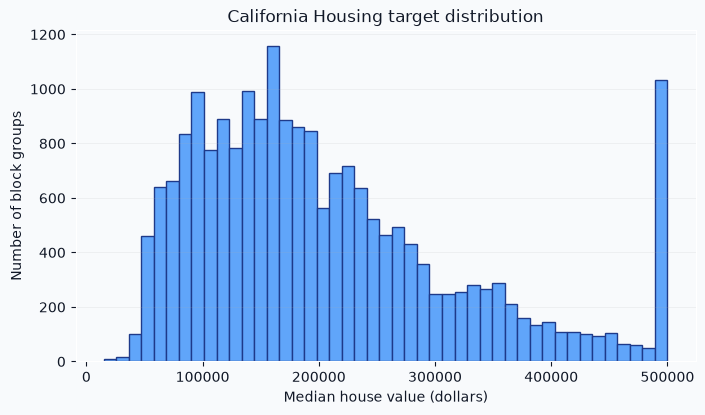

In [2]:
target_figure: Figure
target_axis: Axes
target_figure, target_axis = plt.subplots(figsize=(8, 4.3), facecolor="#f8fafc")
target_axis.set_facecolor("#f8fafc")
target_axis.hist(y_data * 100_000, bins=45, color="#60a5fa", edgecolor="#1e3a8a")
target_axis.set(
    title="California Housing target distribution",
    xlabel="Median house value (dollars)",
    ylabel="Number of block groups",
)
target_axis.tick_params(colors="#111827", labelsize=10)
target_axis.title.set_color("#111827")
target_axis.xaxis.label.set_color("#111827")
target_axis.yaxis.label.set_color("#111827")
target_axis.grid(axis="y", alpha=0.2)
plt.show()


### 2.3 Split first, then normalize using training statistics

Neural networks train more easily when features and targets have similar numerical scales.

We first create training and test sets. We then compute means and standard deviations from the training set only, preventing information from the test set from leaking into training.

The model will predict mean and variance in standardized target units. Later, we convert predictions back to dollars.


In [3]:
X: FloatArray = X_data.copy()
y: FloatArray = y_data.copy()

split_arrays: list[FloatArray] = cast(
    list[FloatArray],
    train_test_split(X, y, test_size=0.20, random_state=SEED),
)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = split_arrays

x_mean: FloatArray = X_train_raw.mean(axis=0)
x_std: FloatArray = X_train_raw.std(axis=0)
y_mean: float = float(y_train_raw.mean())
y_std: float = float(y_train_raw.std())

X_train: FloatArray = ((X_train_raw - x_mean) / x_std).astype(np.float32)
X_test: FloatArray = ((X_test_raw - x_mean) / x_std).astype(np.float32)
y_train: FloatArray = ((y_train_raw - y_mean) / y_std).astype(np.float32)
y_test: FloatArray = ((y_test_raw - y_mean) / y_std).astype(np.float32)

# Limit extreme standardized feature values so a few outliers do not dominate this small demo.
X_train = np.clip(X_train, -8, 8).astype(np.float32)
X_test = np.clip(X_test, -8, 8).astype(np.float32)

X_train_t: Tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_t: Tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_t: Tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_t: Tensor = torch.tensor(y_test, dtype=torch.float32)

print("Training tensors:", X_train_t.shape, y_train_t.shape)
print("Test tensors:    ", X_test_t.shape, y_test_t.shape)
print(f"Training target mean before standardization: ${y_mean * 100_000:,.0f}")
print(f"Training target standard deviation:          ${y_std * 100_000:,.0f}")


Training tensors: torch.Size([16512, 8]) torch.Size([16512])
Test tensors:     torch.Size([4128, 8]) torch.Size([4128])
Training target mean before standardization: $205,895
Training target standard deviation:          $115,227


## Topic 3 — Build the two-output PyTorch model


### 3.1 Deep network architecture

The model has three hidden layers:

$$
8\text{ features}
\rightarrow64
\rightarrow64
\rightarrow32
\rightarrow2\text{ raw outputs}.
$$

The hidden layers learn a representation shared by both distribution parameters. The final layer produces one raw mean and one raw variance score per example.


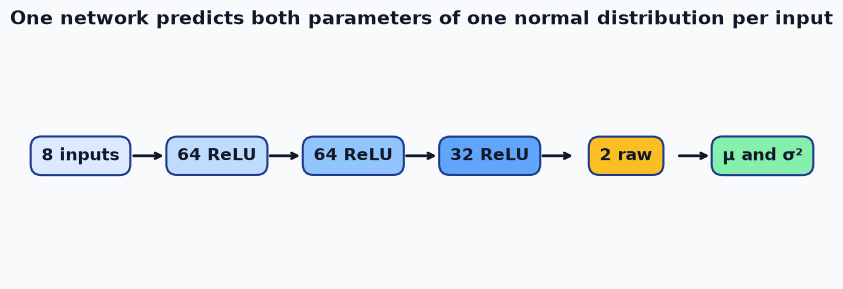

In [4]:
architecture_figure: Figure
architecture_axis: Axes
architecture_figure, architecture_axis = plt.subplots(
    figsize=(10, 3.2), facecolor="#f8fafc"
)
architecture_axis.set_facecolor("#f8fafc")
architecture_axis.axis("off")

layer_labels: list[str] = ["8 inputs", "64 ReLU", "64 ReLU", "32 ReLU", "2 raw", "μ and σ²"]
layer_x_positions: Float64Array = np.linspace(0.06, 0.94, len(layer_labels))
layer_colors: list[str] = ["#dbeafe", "#bfdbfe", "#93c5fd", "#60a5fa", "#fbbf24", "#86efac"]

for layer_index, (x_position, layer_label, layer_color) in enumerate(
    zip(layer_x_positions, layer_labels, layer_colors)
):
    architecture_axis.text(
        x_position,
        0.5,
        layer_label,
        transform=architecture_axis.transAxes,
        ha="center",
        va="center",
        fontsize=12,
        color="#111827",
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.65",
            "facecolor": layer_color,
            "edgecolor": "#1e3a8a",
            "linewidth": 1.5,
        },
    )
    if layer_index < len(layer_labels) - 1:
        architecture_axis.annotate(
            "",
            xy=(layer_x_positions[layer_index + 1] - 0.065, 0.5),
            xytext=(x_position + 0.065, 0.5),
            xycoords=architecture_axis.transAxes,
            arrowprops={"arrowstyle": "->", "color": "#111827", "linewidth": 2},
        )

architecture_axis.set_title(
    "One network predicts both parameters of one normal distribution per input",
    color="#111827",
    fontsize=14,
    fontweight="bold",
)
plt.show()


### 3.2 Why the second raw output needs a transformation

The network's final linear layer can emit any real number, including a negative number. A variance cannot be negative.

We therefore calculate

$$
\sigma_i^2=\operatorname{softplus}(r_i)+10^{-4},
$$

where $r_i$ is the unrestricted second raw output. Softplus maps every real input to a positive value, and the small constant protects numerical stability.

The predicted mean does not need a constraint, so the first raw output is used directly.


In [5]:
class HeteroscedasticRegressor(nn.Module):
    backbone: nn.Sequential
    output_layer: nn.Linear

    def __init__(self, number_of_features: int) -> None:
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(number_of_features, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.output_layer = nn.Linear(32, 2)

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor, Tensor]:
        hidden: Tensor = self.backbone(x)
        raw_outputs: Tensor = self.output_layer(hidden)

        mean: Tensor = raw_outputs[:, 0]
        raw_variance_score: Tensor = raw_outputs[:, 1]
        variance: Tensor = F.softplus(raw_variance_score) + 1e-4

        return mean, variance, raw_outputs


model: HeteroscedasticRegressor = HeteroscedasticRegressor(
    number_of_features=X_train_t.shape[1]
)
number_of_parameters: int = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"Trainable parameters: {number_of_parameters:,}")


HeteroscedasticRegressor(
  (backbone): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
)
Trainable parameters: 6,882


### 3.3 Inspect the outputs before training

The following cell sends five houses through the randomly initialized model.

Notice the distinction:

- `raw_outputs` is the direct two-column tensor emitted by the final linear layer;
- `mean` is column 0;
- `variance` is positive because column 1 passed through softplus.

Training has not happened yet, so the numbers are not useful predictions. Their shapes and roles are what matter.


In [6]:
model.eval()
example_outputs: tuple[Tensor, Tensor, Tensor]
with torch.no_grad():
    example_outputs = model(X_train_t[:5])
example_mean, example_variance, example_raw = example_outputs

print("Direct two-column network output:")
print(example_raw)
print()
print("Interpreted mean:")
print(example_mean)
print()
print("Positive variance after softplus:")
print(example_variance)
print()
print("Shapes:", example_raw.shape, example_mean.shape, example_variance.shape)


Direct two-column network output:
tensor([[-0.1356, -0.1415],
        [-0.1206, -0.1815],
        [-0.1271, -0.1897],
        [-0.1327, -0.1460],
        [-0.1131, -0.1255]])

Interpreted mean:
tensor([-0.1356, -0.1206, -0.1271, -0.1327, -0.1131])

Positive variance after softplus:
tensor([0.6250, 0.6066, 0.6029, 0.6229, 0.6325])

Shapes: torch.Size([5, 2]) torch.Size([5]) torch.Size([5])


## Topic 4 — Gaussian negative log-likelihood


### 4.1 Loss for one observed target

For observation $i$, the network predicts $\mu_i$ and $\sigma_i^2$. The Gaussian negative log-likelihood is

$$
\ell_i
=\frac{1}{2}
\left[
\log(2\pi)
+\log(\sigma_i^2)
+\frac{(y_i-\mu_i)^2}{\sigma_i^2}
\right].
$$

This is Equation 5.15 expressed using variance directly.


### 4.2 Why the model cannot make variance enormous to hide mistakes

The loss contains two competing terms:

$$
\log(\sigma_i^2)
\qquad\text{and}\qquad
\frac{(y_i-\mu_i)^2}{\sigma_i^2}.
$$

- A larger variance reduces the standardized squared-error term.
- But a larger variance increases the log-variance penalty.
- A tiny variance lowers the log term but makes any prediction error extremely expensive.

NLL trains the model to predict both an accurate mean and an honest input-dependent spread.


### 4.3 Verify the formula, then train with PyTorch's built-in loss

Writing the formula once makes every term visible. For the actual training loop, use `nn.GaussianNLLLoss`, which is maintained and tested by PyTorch.

The built-in loss expects arguments in this order:

```python
loss(predicted_mean, observed_target, predicted_variance)
```

Setting `full=True` includes the constant term $	frac{1}{2}\log(2\pi)$, matching the displayed Chapter 5 formula. Omitting that constant would not change the trained parameters, but including it makes the numerical values directly comparable.


In [7]:
def gaussian_nll_from_formula(mean: Tensor, variance: Tensor, target: Tensor) -> Tensor:
    per_example_loss: Tensor = 0.5 * (
        math.log(2 * math.pi)
        + torch.log(variance)
        + (target - mean).pow(2) / variance
    )
    return per_example_loss.mean()


# This is the loss object used by the training and evaluation loops below.
gaussian_nll_loss: nn.GaussianNLLLoss = nn.GaussianNLLLoss(
    full=True, reduction="mean"
)

# Verify the illustrative formula against the built-in implementation once.
manual_nll: Tensor
built_in_nll: Tensor
with torch.no_grad():
    manual_nll = gaussian_nll_from_formula(example_mean, example_variance, y_train_t[:5])
    built_in_nll = gaussian_nll_loss(example_mean, y_train_t[:5], example_variance)
print(f"Manual Gaussian NLL:   {manual_nll.item():.6f}")
print(f"PyTorch Gaussian NLL:  {built_in_nll.item():.6f}")


Manual Gaussian NLL:   2.093343
PyTorch Gaussian NLL:  2.093343


## Topic 5 — Train with a basic PyTorch loop


### 5.1 Mini-batches

A `DataLoader` creates shuffled mini-batches. For every batch, the model returns one mean and one variance per target.


In [8]:
train_dataset: TensorDataset = TensorDataset(X_train_t, y_train_t)
train_loader: DataLoader = DataLoader(train_dataset, batch_size=256, shuffle=True)

first_X: Tensor
first_y: Tensor
first_X, first_y = next(iter(train_loader))
print("One feature batch:", first_X.shape)
print("One target batch: ", first_y.shape)


One feature batch: torch.Size([256, 8])
One target batch:  torch.Size([256])


### 5.2 The complete training loop

Each iteration performs the standard PyTorch sequence:

1. Forward pass: predict means and variances.
2. Calculate Gaussian NLL.
3. Clear old gradients.
4. Backpropagate.
5. Update parameters with Adam.

The network learns distribution parameters because the loss interprets its two outputs as $\mu_i$ and $\sigma_i^2$.


In [9]:
# lr=1e-3 produced steadier NLL optimization than the earlier lr=0.01 experiment.
# weight_decay adds L2 regularization, discouraging large weights to help reduce overfitting.
optimizer: torch.optim.Optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, weight_decay=1e-4
)
number_of_epochs: int = 50
train_losses: list[float] = []
test_losses: list[float] = []

for epoch in range(number_of_epochs):
    model.train()
    total_loss: float = 0.0
    total_examples: int = 0

    for batch_X, batch_y in train_loader:
        predicted_mean: Tensor
        predicted_variance: Tensor
        predicted_mean, predicted_variance, _ = model(batch_X)
        loss: Tensor = gaussian_nll_loss(predicted_mean, batch_y, predicted_variance)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_X.shape[0]
        total_examples += batch_X.shape[0]

    train_losses.append(total_loss / total_examples)

    model.eval()
    test_mean: Tensor
    test_variance: Tensor
    test_loss: float
    with torch.no_grad():
        test_mean, test_variance, _ = model(X_test_t)
        test_loss = gaussian_nll_loss(test_mean, y_test_t, test_variance).item()
    test_losses.append(test_loss)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:02d}/{number_of_epochs}: "
            f"train NLL = {train_losses[-1]:.4f}, test NLL = {test_losses[-1]:.4f}"
        )


Epoch 01/50: train NLL = 1.1908, test NLL = 0.9508
Epoch 10/50: train NLL = 0.5277, test NLL = 0.5553
Epoch 20/50: train NLL = 0.4460, test NLL = 0.4769
Epoch 30/50: train NLL = 0.3892, test NLL = 0.4375
Epoch 40/50: train NLL = 0.3575, test NLL = 0.4221
Epoch 50/50: train NLL = 0.3342, test NLL = 0.3945


### 5.3 Findings: learning rate, weight decay, and apparent overfitting

We first tried Adam with a learning rate of $0.01$. That run was noticeably noisy: training NLL continued to improve, but held-out NLL oscillated and sometimes became worse. This initially looked like pure overfitting, but the aggressive learning rate was also causing optimization instability—particularly important because the variance appears inside both a logarithm and a denominator in Gaussian NLL.

Reducing the learning rate to

$$
10^{-3}=0.001
$$

produced a much steadier decrease:

| Epoch | Training NLL | Held-out NLL |
|---:|---:|---:|
| 1 | $1.1908$ | $0.9508$ |
| 10 | $0.5277$ | $0.5553$ |
| 20 | $0.4460$ | $0.4769$ |
| 30 | $0.3892$ | $0.4375$ |
| 40 | $0.3575$ | $0.4221$ |
| 50 | $0.3342$ | $0.3945$ |

We also use

```python
weight_decay=1e-4
```

as modest L2 regularization. It discourages unnecessarily large weights and can reduce overfitting, but it does not guarantee that overfitting disappears.

The practical conclusion from this experiment is:

- use Adam with `lr=1e-3` for stable optimization;
- retain `weight_decay=1e-4` as mild regularization;
- do not diagnose overfitting from a noisy high-learning-rate run;
- after optimization is stable, diagnose overfitting from a sustained training–validation gap.

This teaching notebook reports held-out performance every epoch, but a production workflow should create separate training, validation, and test sets. Validation NLL should control early stopping and checkpoint selection; the test set should be evaluated only once after those decisions are complete.


### 5.4 Training curves

Both curves show NLL, so they evaluate the quality of the complete predicted distributions—not only the mean predictions.


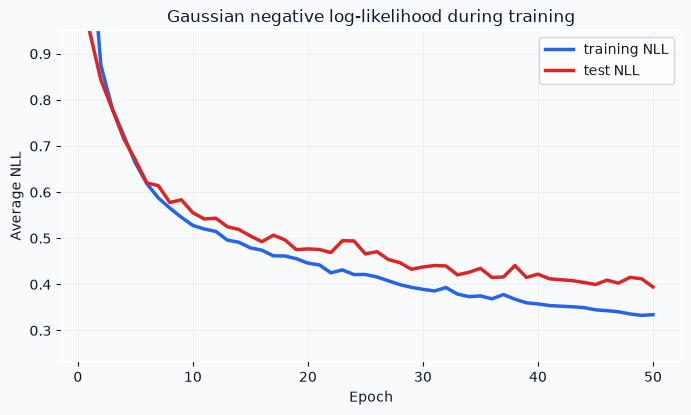

In [10]:
loss_figure: Figure
loss_axis: Axes
loss_figure, loss_axis = plt.subplots(figsize=(8, 4.3), facecolor="#f8fafc")
loss_axis.set_facecolor("#f8fafc")
loss_axis.plot(
    range(1, number_of_epochs + 1),
    train_losses,
    color="#2563eb",
    linewidth=2.5,
    label="training NLL",
)
loss_axis.plot(
    range(1, number_of_epochs + 1),
    test_losses,
    color="#dc2626",
    linewidth=2.5,
    label="test NLL",
)
loss_axis.set(
    title="Gaussian negative log-likelihood during training",
    xlabel="Epoch",
    ylabel="Average NLL",
)
loss_axis.set_ylim(
    bottom=min(min(train_losses), min(test_losses)) - 0.1,
    top=float(np.percentile(test_losses, 95)) + 0.2,
)
loss_axis.tick_params(colors="#111827")
loss_axis.title.set_color("#111827")
loss_axis.xaxis.label.set_color("#111827")
loss_axis.yaxis.label.set_color("#111827")
loss_axis.legend(facecolor="white", labelcolor="#111827")
loss_axis.grid(alpha=0.2)
plt.show()


## Topic 6 — Interpret the learned distributions


### 6.1 Convert means and standard deviations back to dollars

The model trained on standardized targets. Convert the mean with

$$
\mu_{\$}=(\mu_{\text{scaled}}s_y+\bar y)\times100{,}000.
$$

Variance changes with the square of the scale. It is easier to convert standard deviation:

$$
\sigma_{\$}=\sqrt{\sigma_{\text{scaled}}^2}\;s_y\times100{,}000.
$$

The mean is a point prediction. The standard deviation describes the predicted spread around it.


In [11]:
model.eval()
test_output_tensors: tuple[Tensor, Tensor, Tensor]
with torch.no_grad():
    test_output_tensors = model(X_test_t)
mean_scaled, variance_scaled, raw_test_outputs = test_output_tensors

mean_dollars: FloatArray = (
    (mean_scaled.numpy() * y_std + y_mean) * 100_000
).astype(np.float32)
std_dollars: FloatArray = (
    np.sqrt(variance_scaled.numpy()) * y_std * 100_000
).astype(np.float32)
actual_dollars: FloatArray = (y_test_raw * 100_000).astype(np.float32)

rmse: float = float(np.sqrt(np.mean((mean_dollars - actual_dollars) ** 2)))
mae: float = float(np.mean(np.abs(mean_dollars - actual_dollars)))
inside_95: BoolArray = np.asarray(
    np.abs(actual_dollars - mean_dollars) <= 1.96 * std_dollars,
    dtype=np.bool_,
)
coverage_95: float = float(inside_95.mean())

print("Raw test output shape:       ", tuple(raw_test_outputs.shape))
print("Predicted mean shape:        ", mean_dollars.shape)
print("Predicted standard-dev shape:", std_dollars.shape)
print(f"Test RMSE of predicted means: ${rmse:,.0f}")
print(f"Test MAE of predicted means:  ${mae:,.0f}")
print(f"Fraction inside ±1.96σ:       {coverage_95:.1%}")
print(f"Average predicted σ:          ${std_dollars.mean():,.0f}")


Raw test output shape:        (4128, 2)
Predicted mean shape:         (4128,)
Predicted standard-dev shape: (4128,)
Test RMSE of predicted means: $53,606
Test MAE of predicted means:  $35,884
Fraction inside ±1.96σ:       93.9%
Average predicted σ:          $43,816


### 6.2 Means and prediction intervals for individual examples

For readability, the plot shows 60 test examples sorted by predicted mean. Each blue point is $\mu_i$. Each vertical line spans

$$
\mu_i\pm1.96\sigma_i,
$$

which is the model's approximate 95% interval under its normal assumption. Orange crosses are the observed targets.


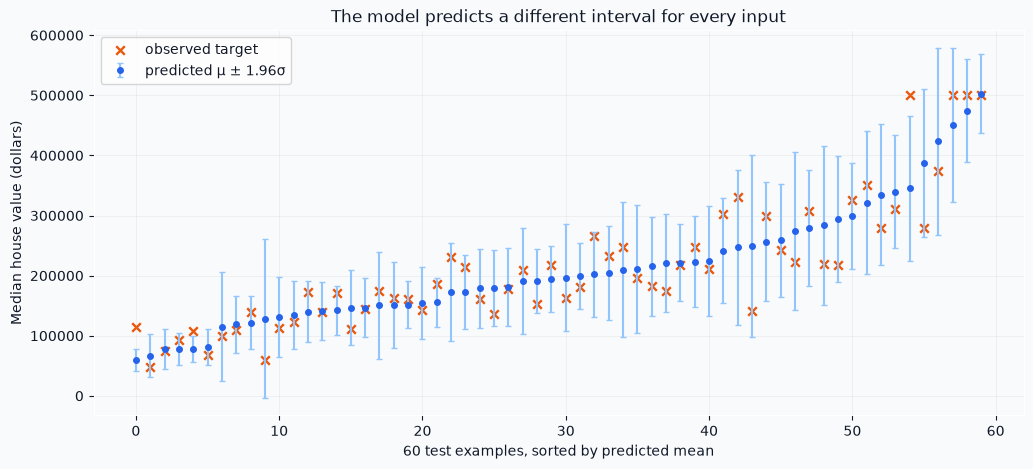

In [12]:
rng: np.random.Generator = np.random.default_rng(SEED)
chosen: IntArray = np.asarray(
    rng.choice(len(actual_dollars), size=60, replace=False), dtype=np.int64
)
chosen = chosen[np.argsort(mean_dollars[chosen])]
positions: IntArray = np.arange(len(chosen), dtype=np.int64)

interval_figure: Figure
interval_axis: Axes
interval_figure, interval_axis = plt.subplots(
    figsize=(12, 5), facecolor="#f8fafc"
)
interval_axis.set_facecolor("#f8fafc")
interval_axis.errorbar(
    positions,
    mean_dollars[chosen],
    yerr=1.96 * std_dollars[chosen],
    fmt="o",
    markersize=4,
    color="#2563eb",
    ecolor="#93c5fd",
    elinewidth=1.5,
    capsize=2,
    label="predicted μ ± 1.96σ",
)
interval_axis.scatter(
    positions,
    actual_dollars[chosen],
    marker="x",
    s=38,
    color="#ea580c",
    linewidth=1.7,
    label="observed target",
)
interval_axis.set(
    title="The model predicts a different interval for every input",
    xlabel="60 test examples, sorted by predicted mean",
    ylabel="Median house value (dollars)",
)
interval_axis.tick_params(colors="#111827")
interval_axis.title.set_color("#111827")
interval_axis.xaxis.label.set_color("#111827")
interval_axis.yaxis.label.set_color("#111827")
interval_axis.legend(facecolor="white", labelcolor="#111827")
interval_axis.grid(alpha=0.2)
plt.show()


### 6.3 Two outputs define an entire density curve

The next plot chooses one relatively low-uncertainty example and one relatively high-uncertainty example.

For each house, the model emitted only two useful values: $\mu$ and $\sigma^2$. Those values determine every point on the displayed normal curve.

A larger $\sigma$ creates a wider, flatter density. A smaller $\sigma$ creates a narrower, taller density.


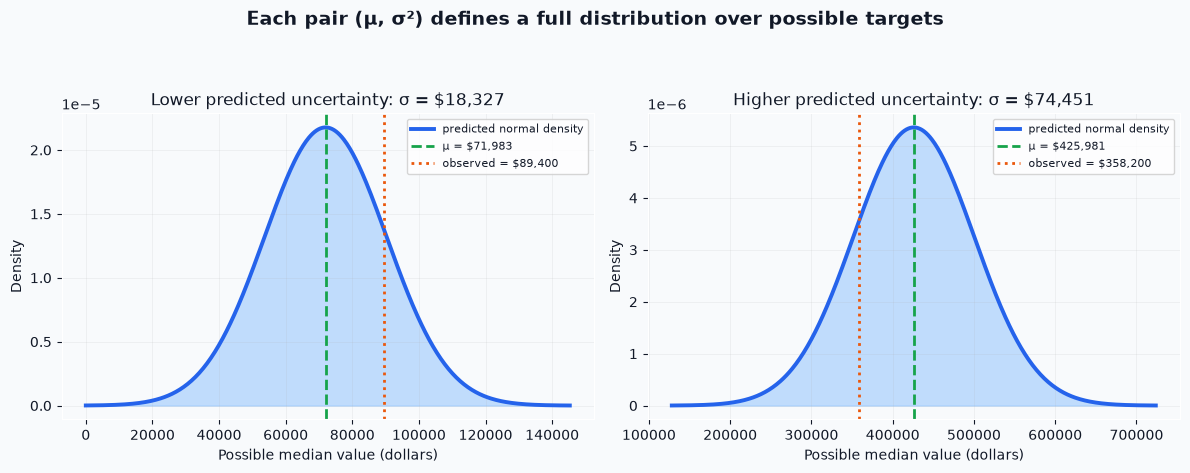

In [13]:
sorted_uncertainty_indices: IntArray = np.argsort(std_dollars).astype(np.int64)
low_index: int = int(sorted_uncertainty_indices[int(0.10 * len(std_dollars))])
high_index: int = int(sorted_uncertainty_indices[int(0.90 * len(std_dollars))])
selected_examples: list[tuple[str, int]] = [
    ("Lower predicted uncertainty", low_index),
    ("Higher predicted uncertainty", high_index),
]

distribution_figure: Figure
distribution_axes: NDArray[np.object_]
distribution_figure, distribution_axes = plt.subplots(
    1, 2, figsize=(12, 4.5), facecolor="#f8fafc"
)
for distribution_axis, (plot_title, example_index) in zip(
    distribution_axes, selected_examples
):
    distribution_axis.set_facecolor("#f8fafc")
    mean_value: float = float(mean_dollars[example_index])
    standard_deviation_value: float = float(std_dollars[example_index])
    price_grid: Float64Array = np.linspace(
        max(0, mean_value - 4 * standard_deviation_value),
        mean_value + 4 * standard_deviation_value,
        500,
    )
    density: Float64Array = (
        np.exp(-0.5 * ((price_grid - mean_value) / standard_deviation_value) ** 2)
        / (np.sqrt(2 * np.pi) * standard_deviation_value)
    )

    distribution_axis.plot(
        price_grid,
        density,
        color="#2563eb",
        linewidth=2.8,
        label="predicted normal density",
    )
    distribution_axis.fill_between(price_grid, density, color="#93c5fd", alpha=0.55)
    distribution_axis.axvline(
        mean_value,
        color="#16a34a",
        linewidth=2,
        linestyle="--",
        label=f"μ = ${mean_value:,.0f}",
    )
    distribution_axis.axvline(
        actual_dollars[example_index],
        color="#ea580c",
        linewidth=2,
        linestyle=":",
        label=f"observed = ${actual_dollars[example_index]:,.0f}",
    )
    distribution_axis.set(
        title=f"{plot_title}: σ = ${standard_deviation_value:,.0f}",
        xlabel="Possible median value (dollars)",
        ylabel="Density",
    )
    distribution_axis.tick_params(colors="#111827")
    distribution_axis.title.set_color("#111827")
    distribution_axis.xaxis.label.set_color("#111827")
    distribution_axis.yaxis.label.set_color("#111827")
    distribution_axis.legend(fontsize=8, facecolor="white", labelcolor="#111827")
    distribution_axis.grid(alpha=0.2)

distribution_figure.suptitle(
    "Each pair (μ, σ²) defines a full distribution over possible targets",
    color="#111827",
    fontsize=14,
    fontweight="bold",
    y=1.04,
)
distribution_figure.tight_layout()
plt.show()


### 6.4 Does larger predicted uncertainty correspond to larger errors?

A useful diagnostic groups test examples by predicted standard deviation. If the model learned meaningful heteroscedasticity, groups with larger predicted uncertainty should generally have larger observed errors.

This does not prove perfect calibration, but it checks whether the variance output contains useful information.


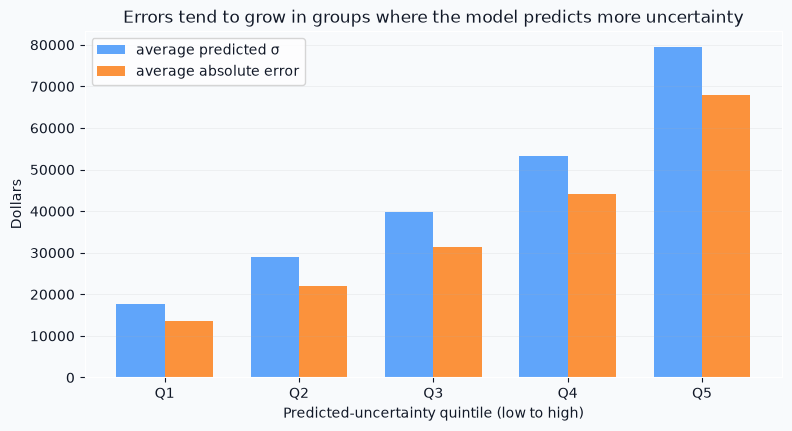

In [14]:
absolute_errors: FloatArray = np.abs(actual_dollars - mean_dollars).astype(np.float32)
quantile_edges: FloatArray = np.quantile(
    std_dollars, np.linspace(0, 1, 6)
).astype(np.float32)
group_names: list[str] = []
average_sigma: list[float] = []
average_error: list[float] = []

for group_index in range(5):
    lower_edge: float = float(quantile_edges[group_index])
    upper_edge: float = float(quantile_edges[group_index + 1])
    uncertainty_mask: BoolArray = np.asarray(
        (std_dollars >= lower_edge)
        & (
            std_dollars <= upper_edge
            if group_index == 4
            else std_dollars < upper_edge
        ),
        dtype=np.bool_,
    )
    group_names.append(f"Q{group_index + 1}")
    average_sigma.append(float(std_dollars[uncertainty_mask].mean()))
    average_error.append(float(absolute_errors[uncertainty_mask].mean()))

quintile_positions: IntArray = np.arange(5, dtype=np.int64)
bar_width: float = 0.36
diagnostic_figure: Figure
diagnostic_axis: Axes
diagnostic_figure, diagnostic_axis = plt.subplots(
    figsize=(9, 4.5), facecolor="#f8fafc"
)
diagnostic_axis.set_facecolor("#f8fafc")
diagnostic_axis.bar(
    quintile_positions - bar_width / 2,
    average_sigma,
    bar_width,
    color="#60a5fa",
    label="average predicted σ",
)
diagnostic_axis.bar(
    quintile_positions + bar_width / 2,
    average_error,
    bar_width,
    color="#fb923c",
    label="average absolute error",
)
diagnostic_axis.set_xticks(quintile_positions, group_names)
diagnostic_axis.set(
    title="Errors tend to grow in groups where the model predicts more uncertainty",
    xlabel="Predicted-uncertainty quintile (low to high)",
    ylabel="Dollars",
)
diagnostic_axis.tick_params(colors="#111827")
diagnostic_axis.title.set_color("#111827")
diagnostic_axis.xaxis.label.set_color("#111827")
diagnostic_axis.yaxis.label.set_color("#111827")
diagnostic_axis.legend(facecolor="white", labelcolor="#111827")
diagnostic_axis.grid(axis="y", alpha=0.2)
plt.show()


## Topic 7 — What changed compared with ordinary regression?


### 7.1 Side-by-side comparison

| Question | Ordinary point regression | Heteroscedastic normal regression |
|---|---|---|
| Final outputs per example | One | Two |
| Interpretation | Predicted target/mean | Predicted mean and variance |
| Typical loss | MSE | Gaussian NLL |
| Point prediction | $\hat y$ | $\mu$ |
| Input-dependent uncertainty | Not represented | $\sigma^2(x)$ |
| Distribution object emitted directly? | No | No—the tensor values parameterize one |

Even ordinary MSE regression can be interpreted probabilistically as predicting a normal mean with fixed variance. The heteroscedastic model makes the variance explicit and input-dependent.


### 7.2 From parameters to possible outcomes

After the model predicts $\mu$ and $\sigma$, a possible target can be sampled as

$$
y_{\text{sample}}=\mu+\sigma\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,1).
$$

The mean remains the best single prediction under squared error. The variance adds a description of plausible spread around that prediction.

The predicted variance represents **aleatoric uncertainty** captured from input-dependent data noise. It should not be interpreted as complete knowledge of model uncertainty or as a guarantee that the normal assumption is correct.


In [15]:
sample_example_index: int = high_index
sample_mean: Tensor = torch.tensor(mean_dollars[sample_example_index])
sample_standard_deviation: Tensor = torch.tensor(std_dollars[sample_example_index])
predicted_distribution: torch.distributions.Normal = torch.distributions.Normal(
    sample_mean, sample_standard_deviation
)
sampled_values: Tensor = predicted_distribution.sample((8,))

print(f"Predicted mean:              ${sample_mean.item():,.0f}")
print(f"Predicted standard deviation:${sample_standard_deviation.item():,.0f}")
print("Eight possible sampled values:")
for sampled_value in sampled_values:
    print(f"  ${sampled_value.item():,.0f}")


Predicted mean:              $425,981
Predicted standard deviation:$74,451
Eight possible sampled values:
  $520,523
  $377,912
  $395,606
  $412,843
  $535,864
  $509,852
  $513,704
  $439,903


### 7.3 Takeaway

For every input house, the trained network returns two ordinary numbers. Our modeling decision gives those numbers meaning:

$$
\text{output 1}\rightarrow\mu(x),
\qquad
\text{output 2}\rightarrow\sigma^2(x)>0.
$$

Gaussian NLL then trains both outputs together.

So regression networks can output raw point estimates, but they can also output parameters of a chosen probability distribution. The architecture, output transformations, and loss function determine which interpretation is used.
